In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from collections import Counter
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from fuzzywuzzy import process
import random

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# reading csvs
ratings = pd.read_csv('/content/drive/MyDrive/ratings.csv')
movies = pd.read_csv('/content/drive/MyDrive/movies.csv')

# Exploratory Data Analysis

In [ ]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
ratings.shape

(100836, 4)

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
movies.shape

(9742, 3)

In [ ]:
# movie and user statistics
num_ratings = ratings.shape[0]
num_movies = ratings['movieId'].nunique()
num_users = ratings['userId'].nunique()
ratings_per_user = round(num_ratings / num_users, 2)
ratings_per_movie = round(num_ratings / num_movies, 2)

print(f'Number of ratings: {num_ratings}')
print(f'Number of movies: {num_movies}')
print(f'Number of users: {num_users}')
print(f'Average ratings per user: {ratings_per_user}')
print(f'Average ratings per movie: {ratings_per_movie}')

Number of ratings: 100836
Number of movies: 9724
Number of users: 610
Average ratings per user: 165.3
Average ratings per movie: 10.37


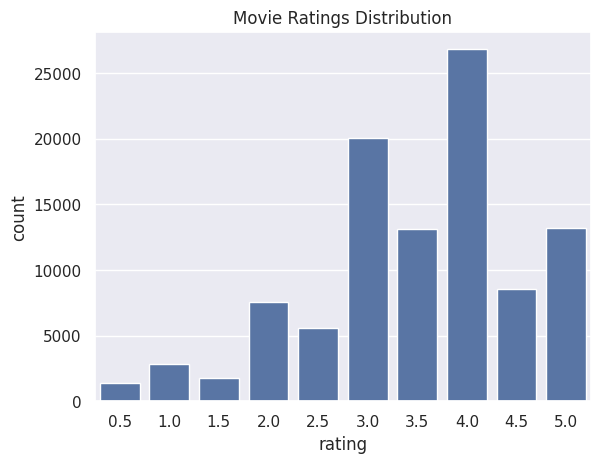

In [ ]:
# movie ratings distribution
sns.countplot(x='rating', data=ratings)
plt.title('Movie Ratings Distribution')
plt.show()

In [ ]:
# global mean rating
print(f'gobal mean rating: {round(ratings['rating'].mean(), 2)}')

gobal mean rating: 3.5


In [ ]:
# mean of average user rating
mean_user_ratings = ratings.groupby('userId')['rating'].mean()
print(f'mean of average rating per user: {round(mean_user_ratings.mean(), 2)}')

mean of average rating per user: 3.66


In [ ]:
# merging ratings with movies
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
# number and mean of ratings per movie
movie_stats = ratings.groupby('movieId')['rating'].agg({'count', 'mean'})
movie_stats.head()

,count,mean
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429


In [ ]:
# bayesian average function to calculate average rating per movie
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
  bayesian_avg = ((C*m + ratings.sum()) / (C + ratings.count()))
  return round(bayesian_avg, 2)

In [ ]:
# bayesian average rating per movie
bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']
bayesian_avg_ratings.head()

,movieId,bayesian_avg
0,1,3.89
1,2,3.42
2,3,3.26
3,4,2.90
4,5,3.10


In [ ]:
# updating movie_stats with the bayesian ratings
movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.head()

,movieId,count,mean,bayesian_avg
0,1,215,3.920930,3.89
1,2,110,3.431818,3.42
2,3,52,3.259615,3.26
3,4,7,2.357143,2.90
4,5,49,3.071429,3.10


In [ ]:
# updating movie_stats with the movie titles
movie_stats = movie_stats.merge(movies[['movieId', 'title']], on='movieId')
movie_stats = movie_stats[['movieId', 'title', 'bayesian_avg', 'count', 'mean']]
movie_stats.head()

,movieId,title,bayesian_avg,count,mean
0,1,Toy Story (1995),3.89,215,3.920930
1,2,Jumanji (1995),3.42,110,3.431818
2,3,Grumpier Old Men (1995),3.26,52,3.259615
3,4,Waiting to Exhale (1995),2.90,7,2.357143
4,5,Father of the Bride Part II (1995),3.10,49,3.071429


In [ ]:
# highest rated movies
movie_stats.sort_values(by='bayesian_avg', ascending=False).head()

,movieId,title,bayesian_avg,count,mean
277,318,"Shawshank Redemption, The (1994)",4.39,317,4.429022
659,858,"Godfather, The (1972)",4.24,192,4.289062
2224,2959,Fight Club (1999),4.23,218,4.272936
224,260,Star Wars: Episode IV - A New Hope (1977),4.19,251,4.231076
921,1221,"Godfather: Part II, The (1974)",4.19,129,4.259690


In [ ]:
# lowest rated movies
movie_stats.sort_values(by='bayesian_avg', ascending=True).head()

,movieId,title,bayesian_avg,count,mean
1172,1556,Speed 2: Cruise Control (1997),2.19,19,1.605263
2679,3593,Battlefield Earth (2000),2.22,19,1.657895
1372,1882,Godzilla (1998),2.27,33,1.954545
1144,1499,Anaconda (1997),2.30,27,1.925926
1988,2643,Superman IV: The Quest for Peace (1987),2.31,16,1.687500


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# splitting genres for each movie to a list
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [ ]:
# counting frequency for each genre, and counting number of unique genres
genre_count = Counter(g for genres in movies['genres'] for g in genres)
n_genres = len(genre_count)
print(f'There are {n_genres} genres.')

There are 20 genres.


In [ ]:
# most common genres
print(f'Most Common Genres: {genre_count.most_common(5)}')

Most Common Genres: [('Drama', 4361), ('Comedy', 3756), ('Thriller', 1894), ('Action', 1828), ('Romance', 1596)]


In [ ]:
# making dataframe of genre frequencies
genre_frequency = pd.DataFrame([genre_count]).T.reset_index()
genre_frequency.columns = ['genre', 'count']
genre_frequency = genre_frequency.sort_values(by='count', ascending=False)
genre_frequency = genre_frequency.reset_index(drop=True)
genre_frequency.head()

,genre,count
0,Drama,4361
1,Comedy,3756
2,Thriller,1894
3,Action,1828
4,Romance,1596


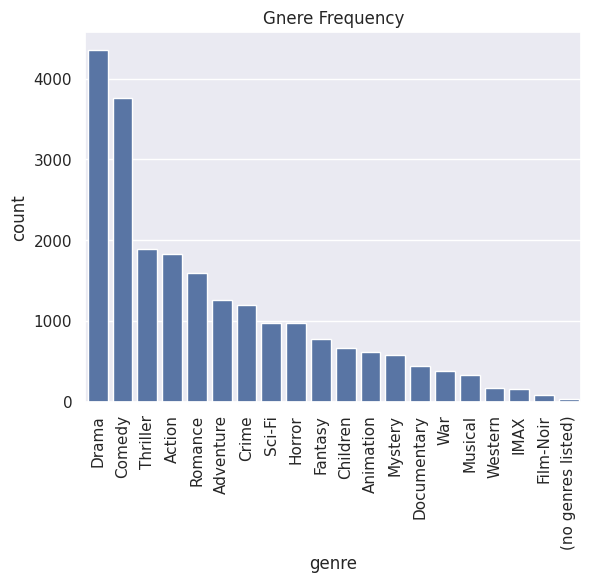

In [ ]:
# plotting genre frequencies
sns.barplot(x='genre', y='count', data=genre_frequency)
plt.title('Gnere Frequency')
plt.xticks(rotation=90)
plt.show()

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [ ]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


# **Recomendation System**

Shared Utilities

In [245]:
# mappers
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()

# movie title - movie id
movie_title_to_id = dict(zip(movies['title'], movies['movieId']))
movie_id_to_title = dict(zip(movies['movieId'], movies['title']))

# movie id - movie row index
movie_id_to_idx = dict(zip(ratings['movieId'].unique(), range(n_movies)))
movie_idx_to_id = dict(zip(range(n_movies), ratings['movieId'].unique()))

# user id - user row index
user_id_to_idx = dict(zip(ratings['userId'].unique(), range(n_users)))
user_idx_to_id = dict(zip(range(n_users), ratings['userId'].unique()))

Simple Collaborative Filtering (Baseline)

In [247]:
# creating the sparse user-movie ratings matrix
def create_X(df):
  user_idx = [user_id_to_idx[i] for i in df['userId']]
  movie_idx = [movie_id_to_idx[i] for i in df['movieId']]

  X = csr_matrix((df['rating'], (user_idx, movie_idx)), (n_users, n_movies))
  return X

In [248]:
# getting the ratings matrix
X = create_X(ratings)

In [249]:
X.shape

(610, 9724)

In [250]:
# checking matrix sparsity
n_total = X.shape[0] * X.shape[1]
n_ratings = X.nnz
sparsity = round((n_ratings / n_total)*100, 2)
print(f'Sparsity: {sparsity}%')

Sparsity: 1.7%


In [251]:
n_ratings_per_user = X.getnnz(axis=1)
print(f'Most active user rated: {n_ratings_per_user.max()} movies')
print(f'Least active user rated: {n_ratings_per_user.min()} movies')

Most active user rated: 2698 movies
Least active user rated: 20 movies


In [252]:
n_ratings_per_movie = X.getnnz(axis=0)
print(f'Most rated movie has: {n_ratings_per_movie.max()} ratings')
print(f'Least rated movie has: {n_ratings_per_movie.min()} ratings')

Most rated movie has: 329 ratings
Least rated movie has: 1 ratings


In [253]:
# finding similar movies using nearest neighbors on the matrix - typically based on cosine similarity
def find_similar_movies(movie_id, matrix, k, metric='cosine'):
  movie_idx = movie_id_to_idx[movie_id]
  movie_vec = matrix[movie_idx]
  movie_vec = movie_vec.reshape(1, -1)

  kNN = NearestNeighbors(n_neighbors=k+1, algorithm='brute', metric=metric)
  kNN.fit(matrix)

  neighbors = kNN.kneighbors(movie_vec, return_distance=False)

  neighbor_movies = []
  for i in range(k):
    n = neighbors.item(i)
    neighbor_movies.append(movie_id_to_title[movie_idx_to_id[n]])

  neighbor_movies.pop(0)

  return neighbor_movies

In [254]:
# getting collaborative based recommendations by cosine similarity
def collaborative_based_recommendations(title, n_recommendations):
  movie_id = movie_title_to_id[title]
  similar_movies = find_similar_movies(movie_id, X.T, k=n_recommendations)
  return similar_movies

Simple Content-Based Filtering (Fallback)

In [255]:
# getting one-hot-encoded movie genre features
genres = set(genre for movie_genres in movies['genres'] for genre in movie_genres)

movies_cb = movies.copy()
for genre in genres:
  movies_cb[genre] = movies_cb['genres'].transform(lambda x: int(genre in x))

movie_genres_matrix = movies_cb.drop(['movieId', 'title', 'genres', '(no genres listed)'], axis=1)
movie_genres_matrix.head()

,Western,War,Crime,Horror,Children,Musical,Comedy,Thriller,Film-Noir,Romance,Animation,Action,Documentary,Mystery,Adventure,Sci-Fi,Drama,IMAX,Fantasy
0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [256]:
# cosine similarity matrix
cosine_sim = cosine_similarity(movie_genres_matrix, movie_genres_matrix)

In [257]:
# getting top n similar movies by cosine similarity on similar genres
def content_based_recommendations(title, n_recommendations):
  idx = movie_id_to_idx[movie_title_to_id[title]]
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  sim_scores = sim_scores[1 : n_recommendations+1]
  similar_movies = [movie_id_to_title[movie_idx_to_id[i[0]]] for i in sim_scores]
  return similar_movies

Collaborative Filtering via Matrix Factorization (Main Model)

In [258]:
# using svd model to get user - latent features matrix and movie - latent features matrix
svd = TruncatedSVD(n_components=20, random_state=42)
user_matrix = svd.fit_transform(X)
movie_matrix = svd.components_.T
print(f'user matrix shape: {user_matrix.shape}\nmovie matrix shape: {movie_matrix.shape}')

user matrix shape: (610, 20)
movie matrix shape: (9724, 20)


In [259]:
# getting similar movies based on collaborative filtering via matrix factorization
def latent_based_recommendations(user_id, n_recommendations):
  user_idx = user_id_to_idx[user_id]
  scores = user_matrix[user_idx].dot(movie_matrix.T)
  rated_movie_indices = X[user_idx].nonzero()[1]
  scores[rated_movie_indices] = -np.inf
  top_movie_indices = np.argsort(scores)[-n_recommendations:][::-1]
  similar_movies = [movie_id_to_title[movie_idx_to_id[i]] for i in top_movie_indices]
  return similar_movies

System Dispatcher

In [264]:
# finding movie title closest to user input
def movie_finder(title):
  all_titles = movies['title'].tolist()
  closest_match = process.extractOne(title, all_titles)
  return closest_match[0]

In [265]:
# printing recomendations
def print_recommendations(movie_watched, recommendations):
  if movie_watched is not None:
    print(f'Since you watched {movie_watched}, we recommend you check out the following movies:\n')
  for movie in recommendations:
    print(f'{movie}')

In [291]:
# system dispatcher: chooses movie title, number of recommendations, and which model to use
# strategy:
# - cf: simple collaborative based filtering
# - mf: collaborative based filtering with matrix factorization
# - cb: content based filtering
# - auto: uses mf as the main model with a fallback to cb if faced with the cold-start problem


def recommend(user_id=None, movie_title=None, n_recommendations=10, strategy='auto'):

  if strategy == 'mf':
    if user_id not in user_id_to_idx:
      raise ValueError("Present User ID must be provided for strategy 'mf'")

    recs = latent_based_recommendations(user_id, n_recommendations)
    print(f'Recommendations for user {user_id}:\n')
    print_recommendations(None, recs)

  elif strategy in ['cf', 'cb', 'auto']:
    if movie_title is None:
      raise ValueError("Movie title must be included for strategies: 'cf', 'cb', or 'auto'.")

    title = movie_finder(movie_title)
    movie_id = movie_title_to_id[title]

    if strategy == 'cf':
      recs = collaborative_based_recommendations(title, n_recommendations)
      print_recommendations(title, recs)

    elif strategy == 'cb':
      recs = content_based_recommendations(title, n_recommendations)
      print_recommendations(title, recs)

    elif strategy == 'auto':

      if user_id in user_id_to_idx:
        recs = latent_based_recommendations(user_id, n_recommendations)
        print(f'Recommendations for user {user_id}:\n')
        print_recommendations(None, recs)

      else:
        recs = content_based_recommendations(title, n_recommendations)
        print_recommendations(title, recs)

  else:
    raise ValueError("Strategy must be one of: 'cf', 'mf', 'cb', or 'auto'.")

In [293]:
# Collaborative Filtering via Matrix Factorization (main model) example
recommend(user_id=25, n_recommendations=5, strategy='mf')

Recommendations for user 25:

Shawshank Redemption, The (1994)
Fight Club (1999)
Forrest Gump (1994)
Star Wars: Episode V - The Empire Strikes Back (1980)
Pulp Fiction (1994)


In [294]:
# Collaborative Filtering (baseline) example
recommend(movie_title='toy story', n_recommendations=5, strategy='cf')

Since you watched Toy Story (1995), we recommend you check out the following movies:

Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)


In [295]:
# Content Based Filtering (fallback) example
recommend(movie_title='despicable me', n_recommendations=5, strategy='cb')

Since you watched Despicable Me (2010), we recommend you check out the following movies:

Fugitive, The (1993)
Three Musketeers, The (1993)
Fargo (1996)
Space Jam (1996)
Winnie the Pooh and the Blustery Day (1968)


In [296]:
# Auto example
recommend(user_id=30, movie_title='karate kid', n_recommendations=5, strategy='auto')

Recommendations for user 30:

Forrest Gump (1994)
Fight Club (1999)
Gladiator (2000)
Back to the Future (1985)
Saving Private Ryan (1998)
